DIAGNOSTIC ANALYSIS

To Find the reasons why sales increased or dropped.

We answer questions like:

Why did revenue drop on certain days?

Which factor affects sales the most?

Why some cities perform better?

Why some fuel types sell more?


 1. CORRELATION ANALYSIS

Correlation with Total_Amount:
 Total_Amount       1.000000
Quantity_Liters    0.995370
Price_per_Litre    0.107486
PumpNumber         0.037209
Name: Total_Amount, dtype: float64


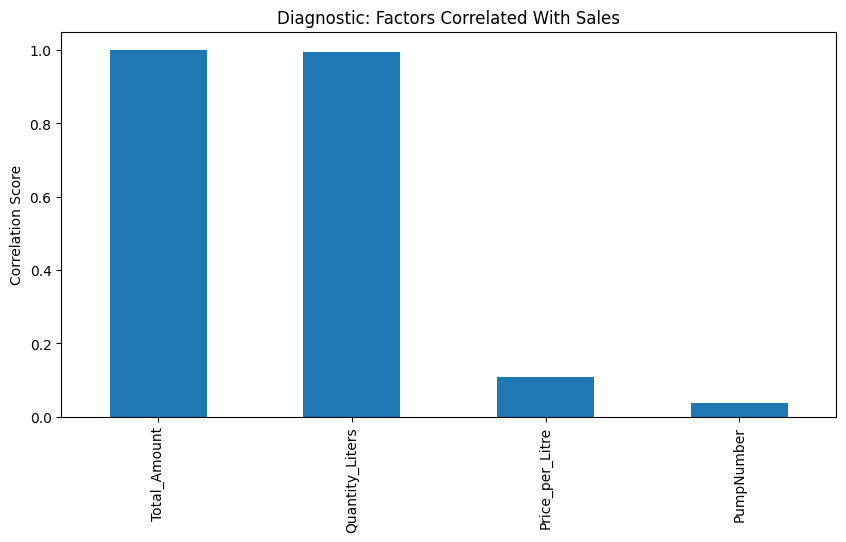

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('final_dataset.csv')


# --- 1️⃣ BASIC DIAGNOSTIC: CORRELATION WITH SALES ---
num_cols = df.select_dtypes(include=['int64', 'float64'])

corr = num_cols.corr()['Total_Amount'].sort_values(ascending=False)
print("Correlation with Total_Amount:\n", corr)

corr.plot(kind='bar', figsize=(10,5), title="Diagnostic: Factors Correlated With Sales")
plt.ylabel("Correlation Score")
plt.show()

FuelType
diesel          1879.070198
petrol          2125.900997
power petrol    2213.830706
Name: Total_Amount, dtype: float64


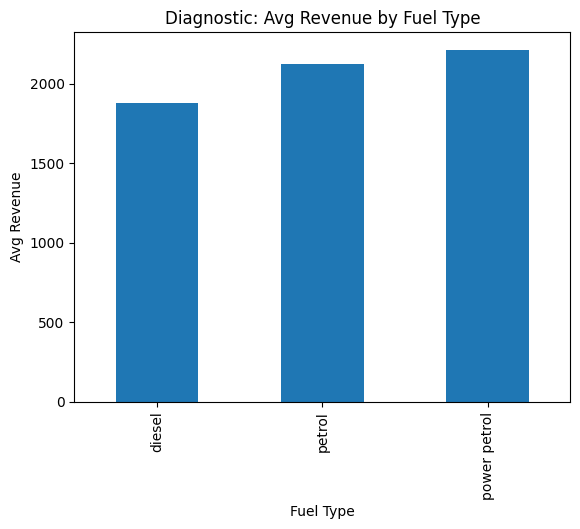

In [39]:

# --- 2️⃣ WHICH FUEL TYPE GENERATES MORE REVENUE? ---
fuel_rev = df.groupby('FuelType')['Total_Amount'].mean().sort_values()
print(fuel_rev)

fuel_rev.plot(kind='bar', title="Diagnostic: Avg Revenue by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Avg Revenue")
plt.show()

2. CITY-WISE SALES DRIVERS

City
mumbai       1971.586844
pune         2042.235088
delhi        2058.058478
chennai      2111.022739
bangalore    2230.690073
Name: Total_Amount, dtype: float64


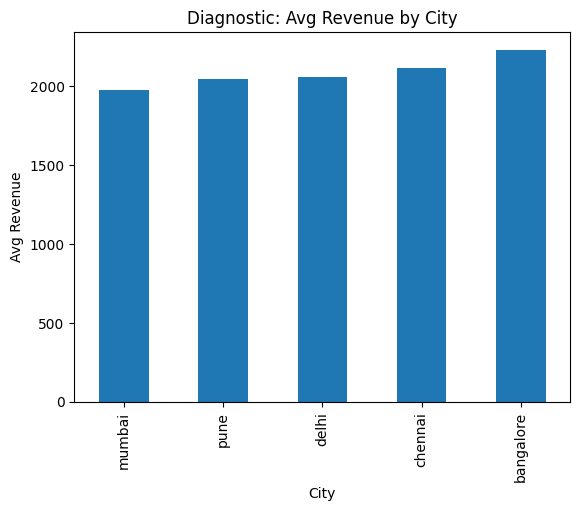

In [40]:
# --- 3️⃣ WHICH CITY PERFORMS BETTER? ---
city_rev = df.groupby('City')['Total_Amount'].mean().sort_values()
print(city_rev)

city_rev.plot(kind='bar', title="Diagnostic: Avg Revenue by City")
plt.xlabel("City")
plt.ylabel("Avg Revenue")
plt.show()


 4️⃣ WHICH PAYMENT METHOD BRINGS HIGH SALES? ---


PaymentMethod
UPI     2001.264072
Cash    2085.381841
Card    2133.556542
Name: Total_Amount, dtype: float64


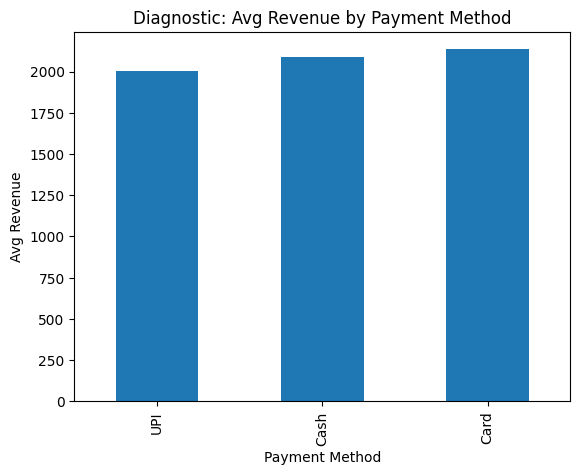

In [41]:

pm_rev = df.groupby('PaymentMethod')['Total_Amount'].mean().sort_values()
print(pm_rev)

pm_rev.plot(kind='bar', title="Diagnostic: Avg Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Avg Revenue")
plt.show()


C:\Users\Keerthish\AppData\Local\Temp\ipykernel_1948\2129539648.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour


hour
0     2304.288056
1     2442.500256
2     1930.305116
3     1901.617959
4     2151.706829
5     2057.801522
6     1841.065435
7     1900.540976
8     2055.008654
9     2086.366522
10    2047.914667
11    1830.511316
12    2173.795263
13    1885.803607
14    2089.047576
15    1950.095128
16    2198.079630
17    1723.446923
18    2022.761509
19    2319.840847
20    2321.882195
21    2234.072549
22    1889.343077
23    2358.485833
Name: Total_Amount, dtype: float64


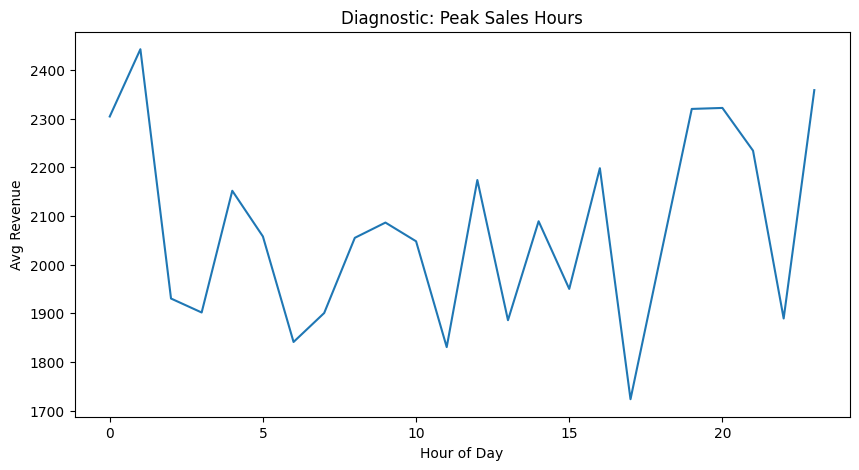

In [42]:
# --- 5️⃣ HOUR-BASED DIAGNOSTIC: Peak business time ---
df['hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

hour_rev = df.groupby('hour')['Total_Amount'].mean()
print(hour_rev)

hour_rev.plot(figsize=(10,5), title="Diagnostic: Peak Sales Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Revenue")
plt.show()

Prescriptive Analysis


In [54]:
import pandas as pd
import re

# ---------------------------------
# LOAD DATASETS
# ---------------------------------
df_2025 = pd.read_csv('final_dataset.csv')
df_2026 = pd.read_csv('forecast_breakdown_2026-01-01_to_2026-01-30.csv')

# ---------------------------------
# CLEAN TIME COLUMN FUNCTION
# ---------------------------------
def clean_time_column(series):
    if series.isna().all():
        return series

    cleaned = series.astype(str)
    cleaned = cleaned.apply(lambda x: re.sub(r"[^0-9]", ":", x))
    cleaned = cleaned.str.replace("::", ":", regex=False)
    cleaned_time = pd.to_datetime(cleaned, format="%H:%M", errors="coerce")
    return cleaned_time

# APPLY CLEANING TO 2025
df_2025['Time_clean'] = clean_time_column(df_2025['Time'])
df_2025['hour'] = df_2025['Time_clean'].dt.hour

# APPLY CLEANING TO 2026 (if exists)
if 'Time' in df_2026.columns:
    df_2026['Time_clean'] = clean_time_column(df_2026['Time'])
    df_2026['hour'] = df_2026['Time_clean'].dt.hour
else:
    df_2026['hour'] = None

print("Time parsing completed successfully.")



Time parsing completed successfully.



# AUTO-DETECT PREDICTED COLUMN

In [ ]:

pred_cols = [
    c for c in df_2026.columns
    if ("total" in c.lower() and ("pred" in c.lower() or "forecast" in c.lower()))
    or c.lower() == "total_amount"
]

print("\nDetected prediction columns:", pred_cols)

if len(pred_cols) == 0:
    raise ValueError(" No predicted Total Amount column found in your forecast dataset.")

pred_col = pred_cols[0]
print("Using predicted column:", pred_col)





Detected prediction columns: ['Predicted_Daily_Total_Amount']
Using predicted column: Predicted_Daily_Total_Amount


COMPARISON AND TRENDS

In [ ]:

# 1  CITY DEMAND COMPARISON
city_25 = df_2025.groupby('City')['Total_Amount'].sum()
city_26 = df_2026.groupby('City')[pred_col].sum()

city_growth = (city_26 - city_25).sort_values(ascending=False)

# 2️ FUEL DEMAND COMPARISON
fuel_25 = df_2025.groupby('FuelType')['Total_Amount'].sum()
fuel_26 = df_2026.groupby('FuelType')[pred_col].sum()

fuel_growth = (fuel_26 - fuel_25).sort_values(ascending=False)

# 3️ PAYMENT METHOD TRENDS
pm_25 = df_2025.groupby('PaymentMethod')['Total_Amount'].sum()
pm_26 = df_2026.groupby('PaymentMethod')[pred_col].sum()

pm_growth = (pm_26 - pm_25).sort_values(ascending=False)

# 4 PEAK HOUR COMPARISON
hour_25 = df_2025.groupby('hour')['Total_Amount'].sum()

if df_2026['hour'].notna().sum() > 0:
    hour_26 = df_2026.groupby('hour')[pred_col].sum()
else:
    hour_26 = None



PRESCPRESCRIPTIVE   

In [ ]:

recommendations = []

# CITY STRATEGY
top_growth_city = city_growth.idxmax()
growth_value_city = city_growth.max()
recommendations.append(
    f"Increase stock & manpower in {top_growth_city} — expected revenue rise of ₹{growth_value_city:.2f} in 2026."
)

# FUEL STRATEGY
top_fuel = fuel_growth.idxmax()
growth_fuel_value = fuel_growth.max()
recommendations.append(
    f"Increase supply of {top_fuel} — fuel demand projected to grow by ₹{growth_fuel_value:.2f}."
)

# PAYMENT METHOD STRATEGY
top_pm = pm_growth.idxmax()
pm_value = pm_growth.max()
recommendations.append(
    f"Promote {top_pm} payments — projected increase of ₹{pm_value:.2f} in digital transactions."
)

# PEAK HOUR STRATEGY
if hour_26 is not None:
    peak_26 = int(hour_26.idxmax())
    recommendations.append(
        f"Deploy extra staff & open more pumps between {peak_26}:00–{peak_26+1}:00 (2026 peak-hour forecast)."
    )
else:
    recommendations.append("Peak hour forecast unavailable due to missing time data in 2026 dataset.")

# DEMAND SURGE CITIES
high_growth_cities = city_growth[city_growth > 0].index.tolist()
recommendations.append(f"Prepare inventory buffers for high-growth cities: {high_growth_cities}")


print("\n FINAL PRESCRIPTIVE RECOMMENDATIONS (2025 ➜ 2026)\n")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")


 FINAL PRESCRIPTIVE RECOMMENDATIONS (2025 ➜ 2026)

1. Increase stock & manpower in bangalore — expected revenue rise of ₹1573945.26 in 2026.
2. Increase supply of power petrol — fuel demand projected to grow by ₹2445863.83.
3. Promote Card payments — projected increase of ₹2361592.13 in digital transactions.
4. Peak hour forecast unavailable due to missing time data in 2026 dataset.
5. Prepare inventory buffers for high-growth cities: ['bangalore', 'delhi', 'chennai', 'mumbai', 'pune']
